Functions for Bayesian best fitting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2
from scipy.interpolate import interp1d
from scipy.special import factorial
import os
import sys
sys.path.append('/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release')
from Astrid.effective_area import bin_edges_to_centers, bin_centers_to_edges, apply_energy_smearing
from simple_backend_setup import create_sampler_with_backend
import nuSIprop

import emcee
import corner

In [2]:
class SuppressOutput:
    """Suppress both Python and C++ prints to stdout and stderr."""
    def __enter__(self):
        # Save original stdout and stderr file descriptors
        self._original_stdout_fd = os.dup(1)
        self._original_stderr_fd = os.dup(2)

        # Open a null file descriptor (redirected to /dev/null)
        self._devnull = os.open(os.devnull, os.O_WRONLY)

        # Override stdout and stderr with the null file descriptor
        os.dup2(self._devnull, 1)
        os.dup2(self._devnull, 2)

    def __exit__(self, exc_type, exc_value, traceback):
        # Restore original stdout and stderr file descriptors
        os.dup2(self._original_stdout_fd, 1)
        os.dup2(self._original_stderr_fd, 2)

        # Close the null file descriptor and original saved descriptors
        os.close(self._devnull)
        os.close(self._original_stdout_fd)
        os.close(self._original_stderr_fd)

In [ ]:
def chi2_poisson(data, predicted):
    # This is the Poisson Deviance which follow a Chi2 distribution?
        
    chi2_value = np.sum(2*(predicted - data) + 2*data*np.log(data/predicted))
    return chi2_value

def log_likelihood_poisson(data, predicted):
    # From Poisson distribution 
    return np.sum(-predicted + data*np.log(predicted) - np.log(factorial(data)))


def total_events(flx, eff, livetime, norm, delta_E, save_to_csv=False):
    # Interpolate `flx` to the same energy bins as `eff`
    flx_interpolated = pd.DataFrame(
    {col: interp1d(flx.index, flx[col], bounds_error=False, fill_value="extrapolate")(eff.index)
     for col in flx.columns},
    index=eff.index)
    
    if eff['nu_e'].any() < 0:
        print('Negative effective area found')
    if eff['nu_mu'].any() < 0:
        print('Negative effective area found')
    if eff['nu_tau'].any() < 0:
        print('Negative effective area found')
    

    total_events_df = flx_interpolated * eff * livetime * norm 
    negative_mask = total_events_df < 0
    total_events_df[negative_mask] = 0
        
    #total_events_df = flx * eff_interpolated * livetime
    total_events_df['total_events'] = delta_E * (total_events_df['nu_e'] + total_events_df['nu_mu'] + total_events_df['nu_tau'])
    #total_events_df.index = eff.index 

    if save_to_csv==True:
        total_events_df.to_csv('total_events.csv')

    return total_events_df

In [5]:
energy_bins = np.logspace(4, 7, 3*20+1)
energy_centers = bin_edges_to_centers(energy_bins)
energy_bins_low_resolution = np.logspace(4, 7, 20+1)
energy_centers_low_resolution = bin_edges_to_centers(energy_bins_low_resolution)

livetime12 = 12*365*24*3600

hese12_events_df = pd.read_csv('4_to_7_HESE12/20bins/hese12_20bins_df.csv', index_col=0)

# Replace all zeros with 1e-8
"""hese12_events_df.loc[hese12_events_df['events'] == 0, 'events'] = 1e-8
print(hese12_events_df)
for i in range(len(hese12_events_df)):
    if hese12_events_df['events'].values[i] < 1e-4:
        hese12_events_df['events'].values[i] = 0"""

print(hese12_events_df['events'].values)

background_df = pd.read_csv('4_to_7_HESE12/20bins/background_20bins_df.csv', index_col=0)
background_df.rename(columns={'background': 'events'}, inplace=True)


effective_area_df = pd.read_csv('4_to_7_HESE12/60bins/effective_area_4_to_7.csv', index_col=0)
#effective_area_df.index = effective_area_df.index * 1e9    # Convert to [eV]   
#effective_area_df['nu_e'] = effective_area_df['nu_e'] * 1e4
#effective_area_df['nu_mu'] = effective_area_df['nu_mu'] * 1e4
#effective_area_df['nu_tau'] = effective_area_df['nu_tau'] * 1e4
#effective_area_df['total'] = effective_area_df['nu_e'] + effective_area_df['nu_mu'] + effective_area_df['nu_tau']

print(effective_area_df)

[ 0  1 18 25 25 23 27 23  8  4  4  1  1  2  0  1  0  1  0  0]
                    nu_e      nu_mu     nu_tau
1.059254e+04    0.000000   0.000000   0.000000
1.188502e+04    0.000000   0.000000   0.000000
1.333521e+04    0.000650   0.000000   0.000000
1.496236e+04    0.001655   0.000000   0.000164
1.678804e+04    0.005214   0.000231   0.000910
1.883649e+04    0.022066   0.001210   0.002558
2.113489e+04    0.043136   0.004113   0.009679
2.371374e+04    0.093632   0.006964   0.016494
2.660725e+04    0.158180   0.013907   0.046911
2.985383e+04    0.259070   0.030709   0.078405
3.349654e+04    0.390221   0.054082   0.131141
3.758374e+04    0.553705   0.082374   0.226340
4.216965e+04    0.774678   0.129672   0.341698
4.731513e+04    1.092296   0.216925   0.507006
5.308844e+04    1.616033   0.291094   0.687900
5.956621e+04    2.114926   0.452367   0.961127
6.683439e+04    2.826941   0.654275   1.425661
7.498942e+04    3.440951   0.891118   1.751250
8.413951e+04    4.221091   1.235720   2.43153

In [ ]:
M_phi = 25
g_phi = 0.05
mntot = 0.1
si = 2.5
norm = 4.0*1e-18

evolver = nuSIprop.pyprop(mphi = M_phi*1e6, # Mediator mass [eV]
			  g = g_phi, # Coupling
			  mntot = mntot, # Sum of neutrino masses [eV]
			  si = si, # Spectral index
			  norm = norm, # Normalization of the free-streaming flux at 100 TeV [Default = 1]
			  majorana = True, # Majorana neutrinos? [Default = True]
			  non_resonant = True, # Include non s-channel contributions? Relevant for couplings g>~0.1 [Default = True]
			  normal_ordering = True, # Normal neutrino mass ordering? [Default = True]
			  N_bins_E = 300, # Number of energy bins, uniformly distributed in log space [Default = 300]
			  lEmin = 13, # log_10 (E_min/eV) [Default = 13]
			  lEmax = 16, # log_10 (E_max/eV) [Default = 17]
			  zmax = 5, # Largest redshift at which sources are included [Default = 5]
			  flav = 2, # Flavor of interacting neutrinos [0=e, 1=mu, 2=tau. Default = 2]
			  phiphi = False # Consider double-scalar production? If set to true, the files xsec/alpha_phiphi.bin and xsec/alphatilde_phiphi.bin must exist [Default = False]
                          )
evolver.evolve()

energies = evolver.get_energies()
bin_edges_high_resolution = bin_centers_to_edges(energies)
delta_E = np.diff(bin_edges_high_resolution)    # Delta E in eV   

In [11]:
def log_Jeffreys_prior(theta):
    #Mphi, g, mntot, si, norm = theta
    #Mphi, g, si, norm = theta
    Mphi, g, si = theta
    
    # Use log-uniform priors for better exploration
    if not (1e-4 < g < 1):
        return -np.inf
    if not (0.1 < Mphi < 1000):
        return -np.inf
    #if not (0.06 < mntot < 0.12):
    #    return -np.inf
    if not (2.0 < si < 3.0):
        return -np.inf
    #if not (1e-19 < norm < 1e-17):  # Much wider range
    #    return -np.inf
    
    # Log-uniform prior: log(1/x) = -log(x)
    #return -np.log(g) - np.log(Mphi) - np.log(norm)
    return -np.log(g) - np.log(Mphi)
    


def log_prior_uniform(theta):
    """
    Uniform prior (for comparison)
    """
    #Mphi, g, mntot, si, norm = theta
    #Mphi, g, si, norm = theta
    Mphi, g, si = theta
    
    # Check bounds
    if not (1e-4 < g < 1):
        return -np.inf
    if not (0.1 < Mphi < 1000):
        return -np.inf
    #if not (0.06 < mntot < 0.12):
    #    return -np.inf
    if not (2.0 < si < 3.0):
        return -np.inf
    #if not (1e-19 < norm < 1e-17):
    #    return -np.inf
    
    # Uniform prior (constant)
    return 0.0




def log_likelihood(theta):
    #Mphi, g, mntot, si, norm = theta
    #Mphi, g, si, norm = theta
    Mphi, g, si = theta

    #evolver.set_parameters(g=g, mphi=Mphi*1e6, mntot=mntot, si=si, norm=norm)
    #evolver.set_parameters(mphi=Mphi*1e6, g=g, si=si, norm=norm)
    evolver.set_parameters(mphi=Mphi*1e6, g=g, si=si)
    evolver.evolve()
    flux = evolver.get_flux_fla()

    flx_df = pd.DataFrame(flux.T, index=energies, columns=['nu_e', 'nu_mu', 'nu_tau'])
    flx_df.index = flx_df.index / 1e9

    nuSIprop_df = total_events(flx=effective_area_df, eff=flx_df, livetime=livetime12, norm=1e-4, delta_E=delta_E)
    nuSIprop_smeared = apply_energy_smearing(energies=nuSIprop_df.index.values, events=nuSIprop_df['total_events'].values, resolution=0.1)
        
    #events = nuSIprop_df['total_events']
    nuSIprop_binned_events, _ = np.histogram(nuSIprop_df.index.values, weights=nuSIprop_smeared, bins=energy_bins_low_resolution)

    predicted = nuSIprop_binned_events + background_df['events'].values
    #chi2 = chi2_poisson(data=hese12_events_df['events'].values, predicted=predicted)
    #return -0.5 * chi2
    return log_likelihood_poisson(data=hese12_events_df['events'].values.astype(int), predicted=predicted)



def log_posterior(theta):

    lp = log_prior_uniform(theta)
    #lp = log_Jeffreys_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood(theta)

    if np.random.random() < 0.03:  # Print 3% of calls
        #print(f"Testing: Mphi={theta[0]:.2f}, g={theta[1]:.2e}, mntot={theta[2]:.2f}, si={theta[3]:.2f}, norm={theta[4]:.2e}")
        #print(f"Testing: Mphi={theta[0]:.2f}, g={theta[1]:.2e}, si={theta[2]:.2f}, norm={theta[3]:.2e}")
        print(f"Testing: Mphi={theta[0]:.2f}, g={theta[1]:.2e}, si={theta[2]:.2f}")
        print(f"Log Prior: {lp:.2f}, Log Likelihood: {ll:.2f}")
    return lp + ll


In [12]:
# Uniform
posterior = log_posterior(theta=[0.1176, 3.22e-4, 2.999])  
print(posterior)

-36.79615369333527


In [ ]:
# Jeffreys
posterior = log_posterior(theta=[0.1176, 3.22e-4, 2.999])
print(posterior)

Testing: Mphi=0.12, g=3.22e-04, si=3.00
Log Prior: 10.18, Log Likelihood: -36.80
-26.614728437397794


Initialize the samplers and positions for each chain/walker, and each parameter dimension.

In [9]:
# Better initial positions with wider spread
nwalkers = 15  # More walkers
ndim = 3

# Much wider initial spread
pos = np.zeros((nwalkers, ndim))
for i in range(nwalkers):
    log_M_phi = np.random.uniform(-1, 3)      # M_phi, log space
    pos[i, 0] = 10**log_M_phi
    log_g = np.random.uniform(-4, 0)  # g, log space
    pos[i, 1] = 10**log_g
    #pos[i, 2] = np.random.uniform(0.06, 0.12)  # Sum of neutrino masses, linear space
    pos[i, 2] = np.random.uniform(2.0, 3.0)   # si, linear space
    #log_norm = np.random.uniform(-19, -17) # norm, log space
    #pos[i, 3] = 10**log_norm

print(pos)

[[4.46664891e+01 1.20382411e-01 2.50020037e+00]
 [3.03054042e+01 8.03512677e-03 2.97371026e+00]
 [3.82028074e+02 1.98331720e-01 2.89601411e+00]
 [6.71670857e+00 3.43750058e-03 2.71199137e+00]
 [7.10522492e+00 8.73661600e-01 2.27049016e+00]
 [2.16927988e-01 5.37357589e-03 2.53263614e+00]
 [2.69325917e+02 3.29761374e-04 2.76617964e+00]
 [4.81359602e+01 5.93239169e-01 2.20870348e+00]
 [7.76619693e+00 9.59392293e-04 2.18956702e+00]
 [3.49557057e-01 3.15071703e-04 2.58601614e+00]
 [5.87625715e+00 3.19091929e-04 2.93899170e+00]
 [1.16088859e+00 3.25166386e-01 2.68555874e+00]
 [1.44435580e+01 5.23532011e-02 2.19287275e+00]
 [2.58527334e+02 6.76909394e-04 2.40667734e+00]
 [5.74752079e+00 5.06079923e-02 2.76014778e+00]]


Same code as below, but with uniform prior instead of Jeffreys. 15 walkers, 2000 iterations. Full log likelihood included. Norm fixed to 4e-18.

In [13]:
sampler_uniform = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)

sampler_uniform.run_mcmc(pos, 2000, progress=True)

#sampler_uniform.get_chain()

  0%|          | 3/2000 [00:48<8:55:00, 16.07s/it]

Testing: Mphi=6.13, g=1.34e-02, si=2.55
Log Prior: 0.00, Log Likelihood: -44.73


  0%|          | 10/2000 [02:53<10:20:36, 18.71s/it]

Testing: Mphi=6.59, g=2.49e-01, si=2.48
Log Prior: 0.00, Log Likelihood: -116.18


  1%|          | 15/2000 [04:39<11:42:06, 21.22s/it]

...

100%|█████████▉| 1991/2000 [24:31:51<02:13, 14.88s/it]

Testing: Mphi=651.87, g=7.36e-01, si=2.97
Log Prior: 0.00, Log Likelihood: -37.21


100%|██████████| 2000/2000 [24:34:08<00:00, 44.22s/it]

Testing: Mphi=503.51, g=5.55e-01, si=2.99
Log Prior: 0.00, Log Likelihood: -36.89
Testing: Mphi=479.39, g=3.37e-01, si=2.93
Log Prior: 0.00, Log Likelihood: -37.94


State([[9.60912362e+02 9.15171879e-02 2.98767299e+00]
 [4.97386627e+02 6.91010395e-01 2.93644190e+00]
 [4.56378799e+01 2.02368209e-01 2.99626667e+00]
 [8.62289678e+02 3.39804103e-01 2.98515579e+00]
 [5.63989012e+00 4.19460353e-02 2.83333853e+00]
 [6.06547974e+02 7.51114258e-02 2.93059540e+00]
 [8.79028671e+02 3.89390367e-01 2.97881059e+00]
 [9.89340297e+02 3.55478557e-02 2.87613188e+00]
 [9.07014469e+02 4.94441457e-01 2.95062385e+00]
 [6.71230508e+02 4.61267142e-01 2.96387656e+00]
 [6.32265023e+01 9.66438421e-01 2.79991986e+00]
 [6.90428508e+01 9.65207335e-01 2.83924026e+00]
 [5.03509259e+02 5.54770766e-01 2.99192285e+00]
 [4.79394946e+02 3.36976299e-01 2.92576937e+00]
 [3.57229416e+02 9.22971363e-03 2.99423255e+00]], log_prob=[-36.94247615 -37.74107206 -36.84162964 -36.97660928 -32.67865502
 -37.84872406 -37.06466816 -38.9956391  -37.49762331 -37.28537992
 -38.13794317 -37.36622942 -36.88640588 -37.93871546 -36.85643287], blobs=None, random_state=('MT19937', array([4176795906, 2879547

To analyze your completed MCMC:
1. Run: results = analyze_completed_mcmc(sampler)
2. Run: plot_comprehensive_results(sampler)
3. Run: check_for_backend_files()
4. Run: print_best_fit_summary(results)

To load MCMC data from CSV files:
1. Load from parameter samples: sampler = load_sampler_from_csv('mcmc_parameter_samples.csv')
2. Load with log probability: sampler = load_sampler_with_log_prob('mcmc_parameter_samples.csv', 'mcmc_log_prob.csv')
3. Then use any analysis function: results = analyze_completed_mcmc(sampler)

To load MCMC data from .npy files:
1. Load from .npy files: sampler = load_sampler_from_npy('mcmc_chain.npy', 'mcmc_log_prob_final.npy')
2. Load with just log probability .npy: sampler = load_sampler_with_log_prob('mcmc_parameter_samples.csv', 'mcmc_log_prob_final.npy')
=== COMPLETED MCMC ANALYSIS ===
Final results:
  Total iterations completed: 2000
  Number of walkers: 15
  Number of parameters: 3
  Likelihood range: -140.84 to -32.13
  Best fit found at iteration 600 

  Parameter samples saved to 'plots/bayesian_fitting/2000steps_15walkers_uniform/mcmc_parameter_samples.csv'
  Summary statistics saved to 'plots/bayesian_fitting/2000steps_15walkers_uniform/mcmc_summary_statistics.csv'

Creating comprehensive plots...
  Chain evolution plot saved to 'plots/bayesian_fitting/2000steps_15walkers_uniform/mcmc_chain_evolution.png'


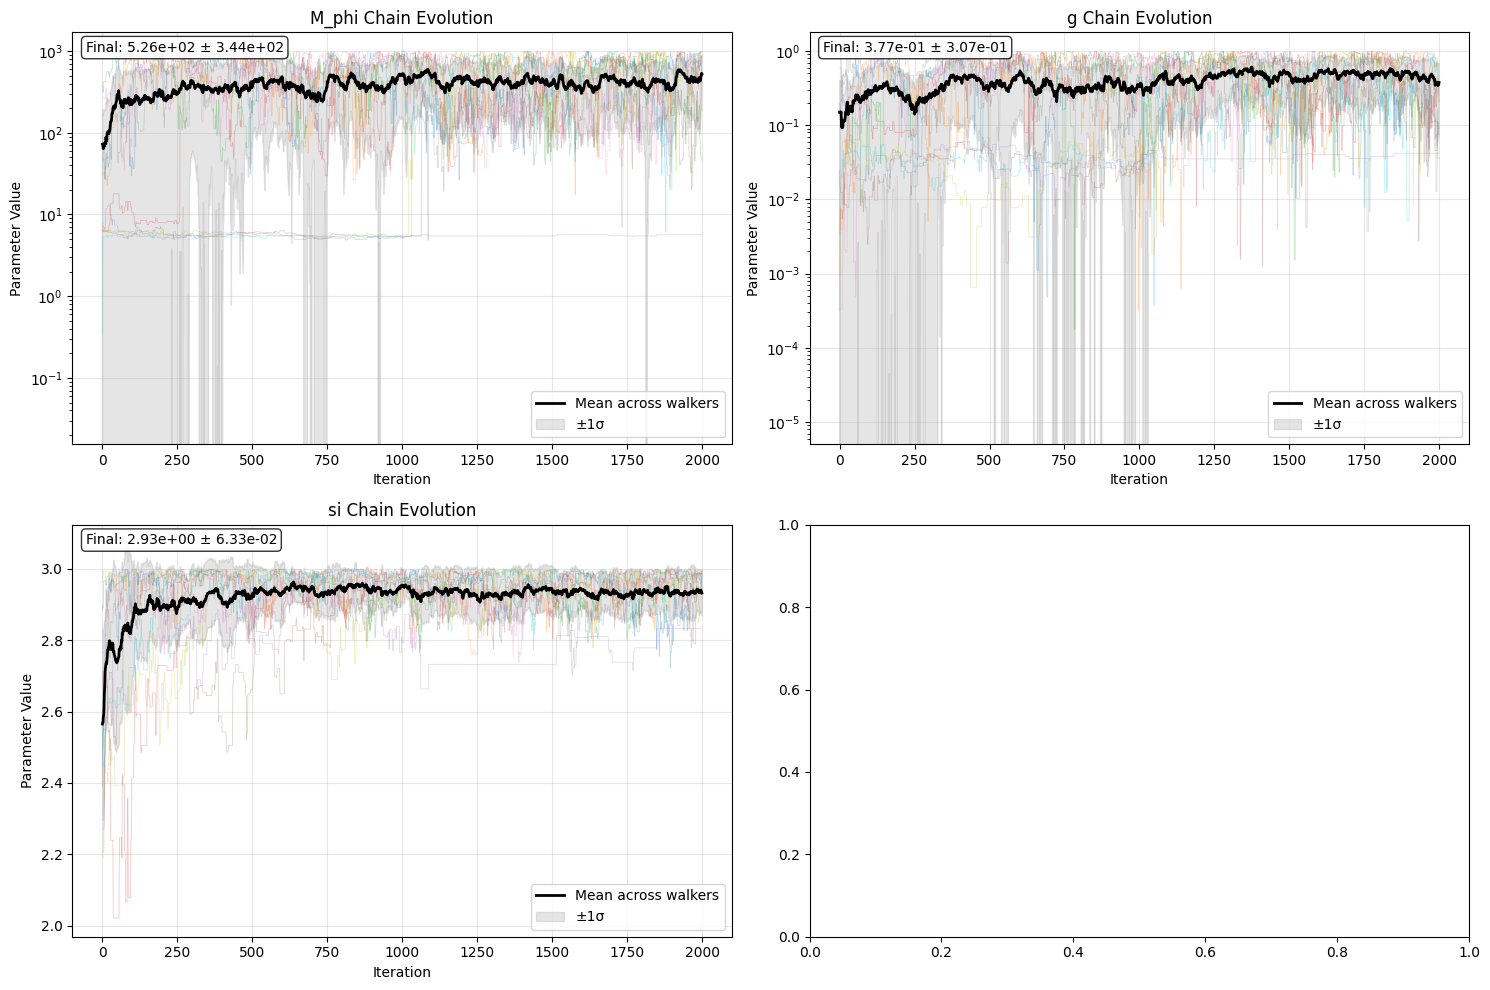

  Corner plot saved to 'plots/bayesian_fitting/2000steps_15walkers_uniform/mcmc_corner_plot.png'


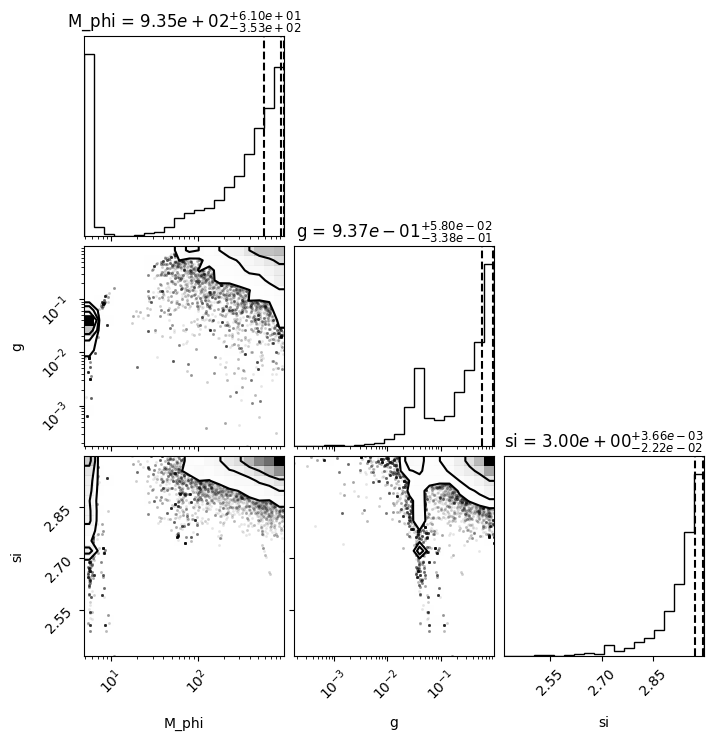

log prob shape (2000, 15)
Infinite log probabilities: 0/30000 (0.0%)
mean log prob [-66.89164996621916 -65.431642493887 -64.69219319673427 ...
 -37.1180568020618 -37.11407163188893 -37.13721356546577]
  Likelihood evolution plot saved to 'plots/bayesian_fitting/2000steps_15walkers_uniform/mcmc_likelihood_evolution.png'


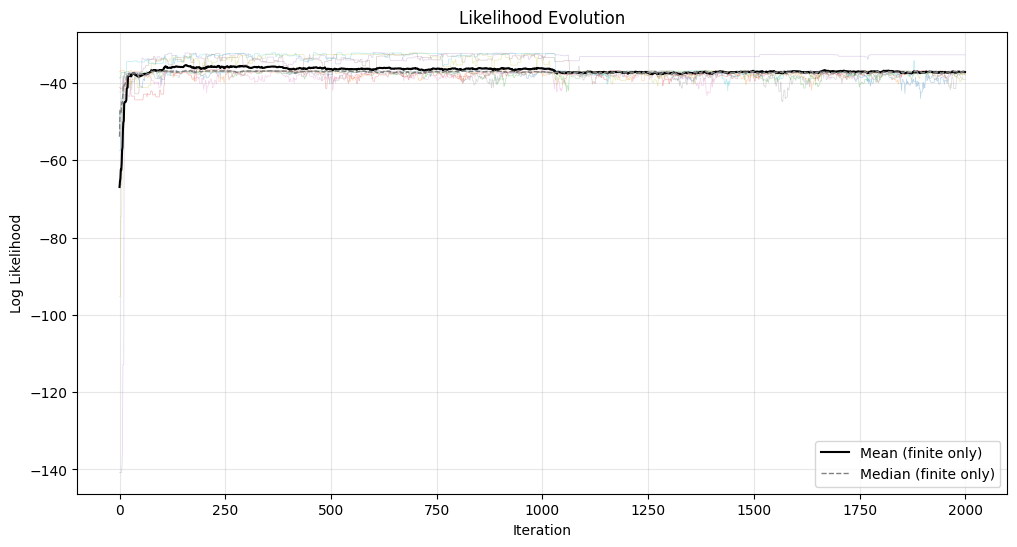

  Acceptance rate distribution saved to 'plots/bayesian_fitting/2000steps_15walkers_uniform/mcmc_acceptance_distribution.png'


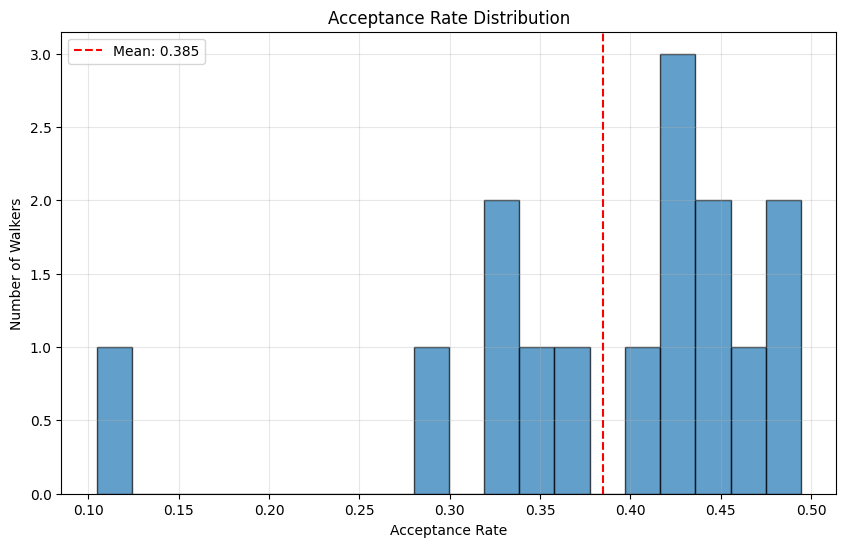

In [16]:
# Code for 2000 iterations, 15 walkers, uniform prior, fixed norm=4e-18.

exec(open('analyze_completed_mcmc.py').read())
folder = 'plots/bayesian_fitting/2000steps_15walkers_uniform'
results = analyze_completed_mcmc(sampler_uniform, save_results=True, folder_name=folder)
plot_comprehensive_results(sampler_uniform, folder_name=folder)

Factorial term included. Norm fixed to 4e-18 (best value). 15 walkers.

In [10]:
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)

sampler.run_mcmc(pos, 2000, progress=True)

Testing: Mphi=0.56, g=9.67e-03, si=2.26
Log Prior: 5.22, Log Likelihood: -87.28


  0%|          | 9/2000 [02:06<7:53:48, 14.28s/it]

Testing: Mphi=723.28, g=2.27e-02, si=2.83
Log Prior: -2.80, Log Likelihood: -40.06


  0%|          | 10/2000 [02:21<8:09:01, 14.74s/it]Negative cross section when computing Gamma; for sminus/mphi^2 = 5.70755e-07, splus/mphi^2 = 5.8405e-07. The values of Gamma are as follows:
Gamma_s = 2.94899e-47
Gamma_t_u = 1.75461e-47
Gamma_tu = 5.64856e-48
Gamma_s + Gamma_t_u + Gamma_st + Gamma_su = -4.92053e-49
Possible roundoff errors for g=0.000835242, mphi=9.17461e+08, mntot=0.1
Negative cross section when computing Gamma; for sminus/mphi^2 = 6.096e-07, splus/mphi^2 = 6.238e-07. The values of Gamma are as follows:
Gamma_s = 2.46951e-47
Gamma_t_u = 1.71426e-47
Gamma_tu = 4.95132e-48
Gamma_s + Gamma_t_u + Gamma_st + Gamma_su = -9.39174e-49
Possible roundoff errors for g=0.000835242, mphi=9.17461e+08, mntot=0.1
  1%|          | 12/2000 [02:58<9:11:26, 16.64s/it]

Testing: Mphi=28.49, g=4.17e-04, si=2.78
Log Prior: 4.43, Log Likelihood: -41.95


...

Testing: Mphi=402.97, g=6.93e-03, si=2.95
Log Prior: -1.03, Log Likelihood: -37.51


100%|█████████▉| 1993/2000 [9:54:28<02:00, 17.17s/it]

Testing: Mphi=4.93, g=7.64e-03, si=2.90
Log Prior: 3.28, Log Likelihood: -34.74
Testing: Mphi=862.58, g=1.82e-01, si=2.95
Log Prior: -5.06, Log Likelihood: -37.43
Testing: Mphi=5.29, g=2.25e-03, si=2.94
Log Prior: 4.43, Log Likelihood: -33.07


100%|██████████| 2000/2000 [9:56:37<00:00, 17.90s/it]


State([[5.47249967e+00 6.75935692e-04 2.99214767e+00]
 [3.67778108e+02 1.35125952e-04 2.91860419e+00]
 [5.81659993e+00 4.00102923e-03 2.92169854e+00]
 [5.33540873e+00 4.10136152e-03 2.94984312e+00]
 [1.05551179e+02 1.29305166e-02 2.94046148e+00]
 [5.95802538e+00 2.66057318e-02 2.95632603e+00]
 [6.13407982e+00 2.69009115e-03 2.90790837e+00]
 [5.94220595e+00 4.86050710e-02 2.80616715e+00]
 [5.21924200e+00 3.91471440e-03 2.94699747e+00]
 [4.37438353e+01 4.14591175e-04 2.98511321e+00]
 [3.70367655e+02 5.58821321e-02 2.92509646e+00]
 [3.47062508e+01 9.97597167e-02 2.86871240e+00]
 [5.39927619e+00 5.83400470e-04 2.95715540e+00]
 [4.29317411e+01 7.05654030e-02 2.96419764e+00]
 [3.46370690e+02 1.83162339e-03 2.96970067e+00]], log_prob=[-27.73668698 -35.07478683 -29.63430196 -29.0385048  -37.98228561
 -31.00645204 -30.29197692 -32.33083712 -29.25537549 -32.96543845
 -40.98153817 -40.27818044 -28.02485142 -38.33427335 -36.7418882 ], blobs=None, random_state=('MT19937', array([   7856191, 1110730

Testing with updated log likelihood. Factorial term omitted.

To analyze your completed MCMC:
1. Run: results = analyze_completed_mcmc(sampler)
2. Run: plot_comprehensive_results(sampler)
3. Run: check_for_backend_files()
4. Run: print_best_fit_summary(results)

To load MCMC data from CSV files:
1. Load from parameter samples: sampler = load_sampler_from_csv('mcmc_parameter_samples.csv')
2. Load with log probability: sampler = load_sampler_with_log_prob('mcmc_parameter_samples.csv', 'mcmc_log_prob.csv')
3. Then use any analysis function: results = analyze_completed_mcmc(sampler)

To load MCMC data from .npy files:
1. Load from .npy files: sampler = load_sampler_from_npy('mcmc_chain.npy', 'mcmc_log_prob_final.npy')
2. Load with just log probability .npy: sampler = load_sampler_with_log_prob('mcmc_parameter_samples.csv', 'mcmc_log_prob_final.npy')
=== COMPLETED MCMC ANALYSIS ===
Final results:
  Total iterations completed: 2000
  Number of walkers: 15
  Number of parameters: 3
  Likelihood range: -128.04 to -26.61
  Best fit found at iteration 1401

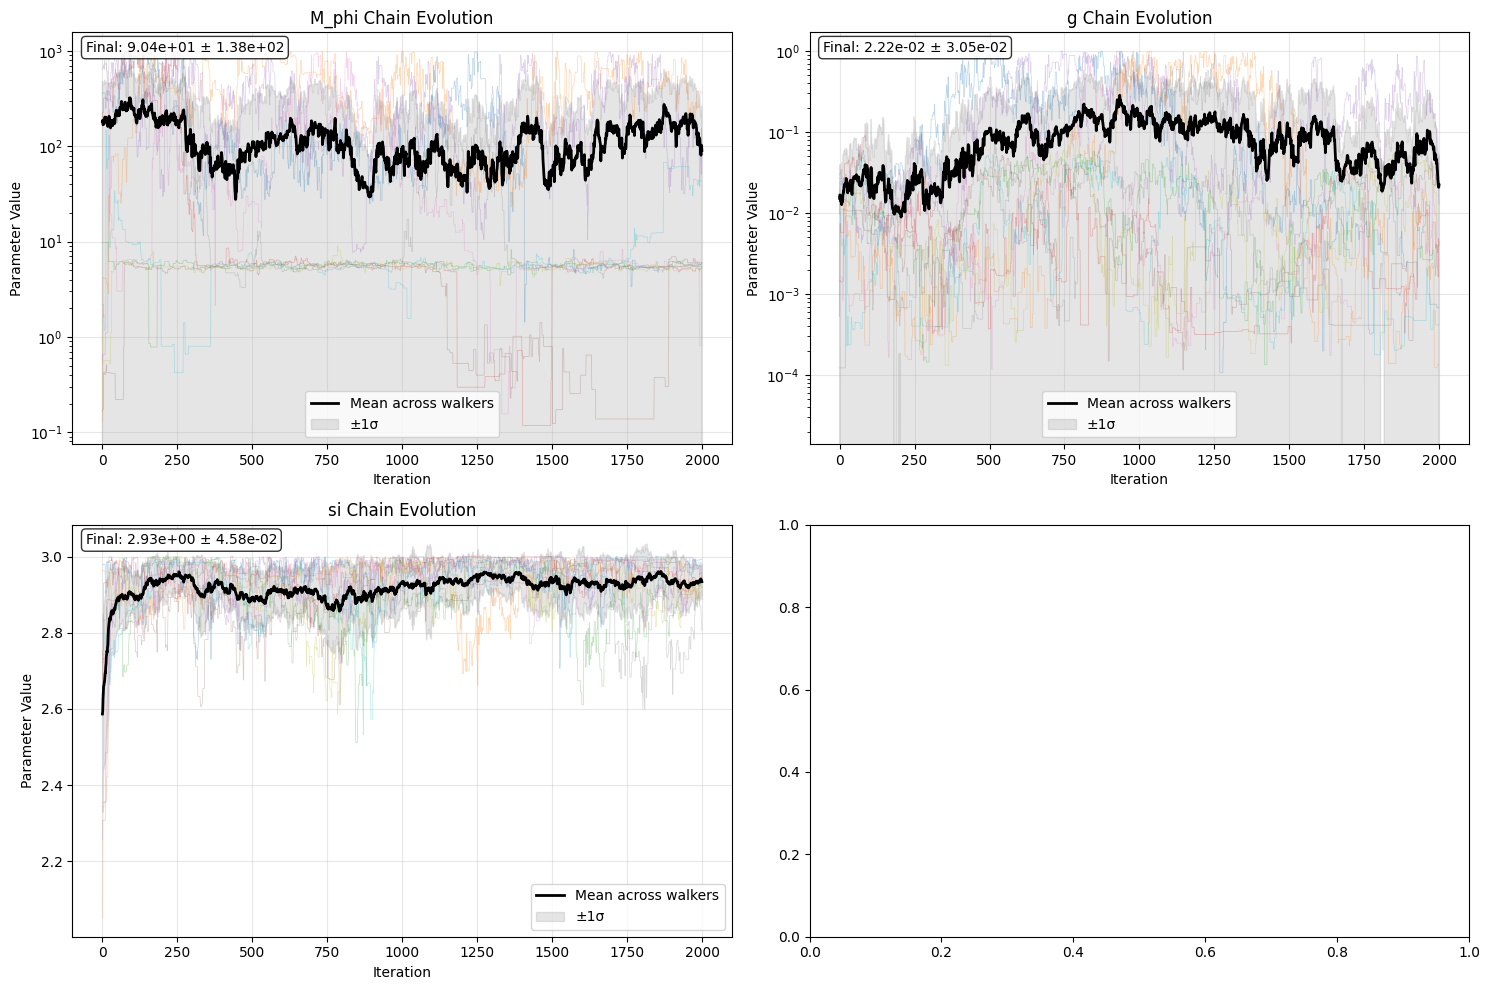

  Corner plot saved to 'plots/bayesian_fitting/2000steps_15walkers/mcmc_corner_plot.png'


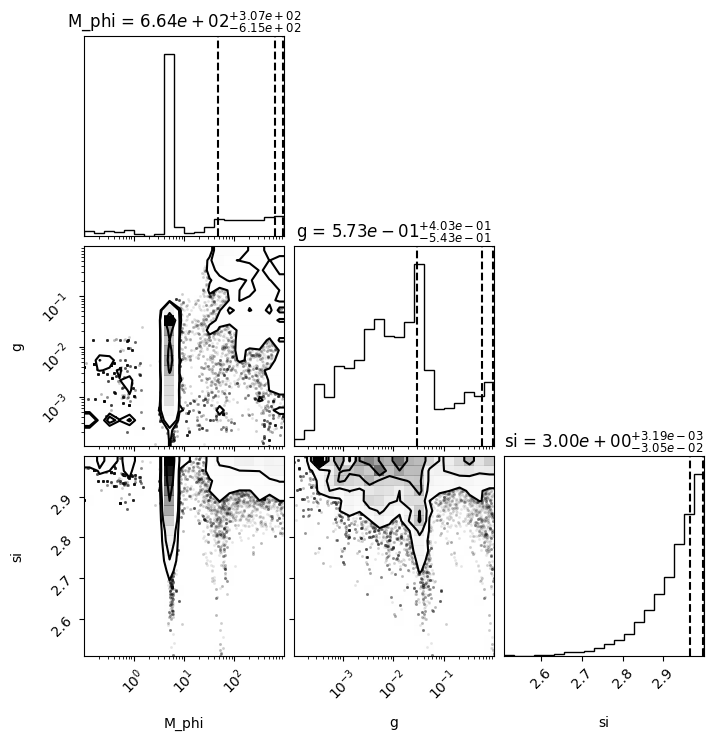

log prob shape (2000, 15)
Infinite log probabilities: 0/30000 (0.0%)
mean log prob [-59.2640145756969 -58.70240290842519 -52.82697591400636 ...
 -33.2736523173727 -33.28470642508067 -33.31182518581753]
  Likelihood evolution plot saved to 'plots/bayesian_fitting/2000steps_15walkers/mcmc_likelihood_evolution.png'


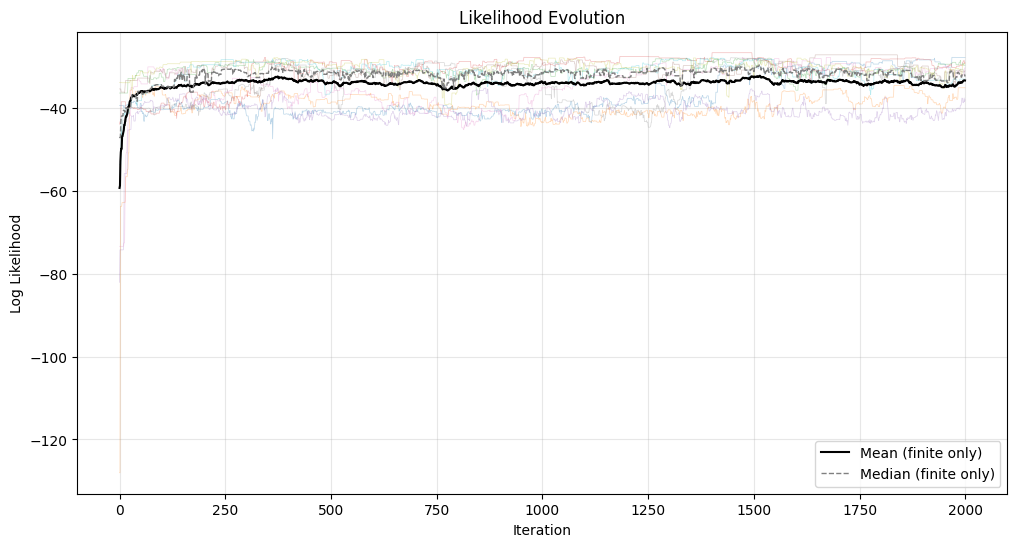

  Acceptance rate distribution saved to 'plots/bayesian_fitting/2000steps_15walkers/mcmc_acceptance_distribution.png'


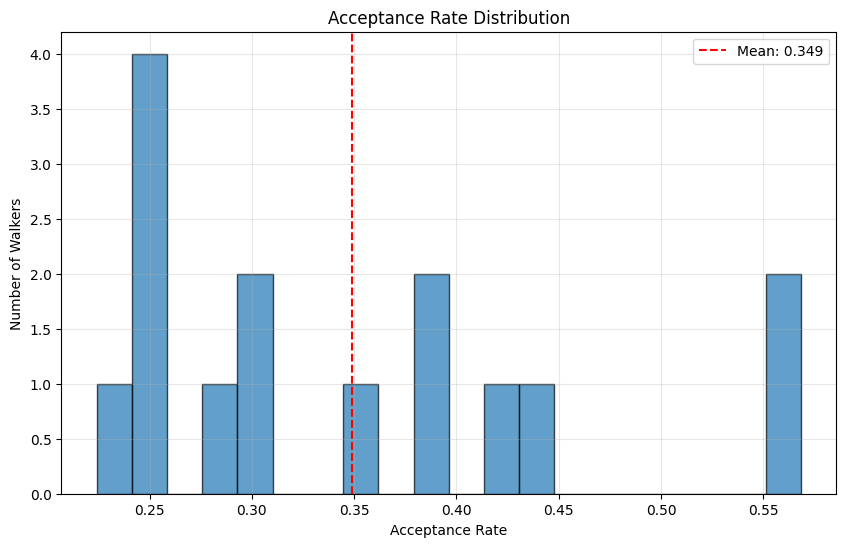

In [15]:
exec(open('analyze_completed_mcmc.py').read())
folder = 'plots/bayesian_fitting/2000steps_15walkers'
results = analyze_completed_mcmc(sampler, save_results=True, folder_name=folder)
plot_comprehensive_results(sampler, folder_name=folder)

In [24]:
chain = np.load('plots/bayesian_fitting/2000steps_15walkers_jeffreys/mcmc_chain_final.npy')
tau = emcee.autocorr.integrated_time(chain)
print(tau)

n_eff = len(chain.flatten()) / np.max(tau)
print(n_eff)

AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 40;
tau: [132.76382841 112.58131464 101.75884375]

In [26]:
chain_5000 = np.load('plots/bayesian_fitting/5000steps_poiss_l_jeffreys_?/mcmc_chain_final.npy')
tau_5000 = emcee.autocorr.integrated_time(chain_5000)
n_eff_5000 = len(chain_5000.flatten()) / np.max(tau_5000)
print(tau_5000)
print(n_eff_5000)



AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 100;
tau: [331.89902608 306.80622143 156.86954796 238.55112534]

5000 iterations, 17 walkers, poissonian likelihood. Factorial term omitted.

To analyze your completed MCMC:
1. Run: results = analyze_completed_mcmc(sampler)
2. Run: plot_comprehensive_results(sampler)
3. Run: check_for_backend_files()
4. Run: print_best_fit_summary(results)

To load MCMC data from CSV files:
1. Load from parameter samples: sampler = load_sampler_from_csv('mcmc_parameter_samples.csv')
2. Load with log probability: sampler = load_sampler_with_log_prob('mcmc_parameter_samples.csv', 'mcmc_log_prob.csv')
3. Then use any analysis function: results = analyze_completed_mcmc(sampler)

To load MCMC data from .npy files:
1. Load from .npy files: sampler = load_sampler_from_npy('mcmc_chain.npy', 'mcmc_log_prob_final.npy')
2. Load with just log probability .npy: sampler = load_sampler_with_log_prob('mcmc_parameter_samples.csv', 'mcmc_log_prob_final.npy')
=== COMPLETED MCMC ANALYSIS ===
Final results:
  Total iterations completed: 5000
  Number of walkers: 17
  Number of parameters: 4
  Likelihood range: -inf to 353.00
  Best fit found at iteration 2415 by

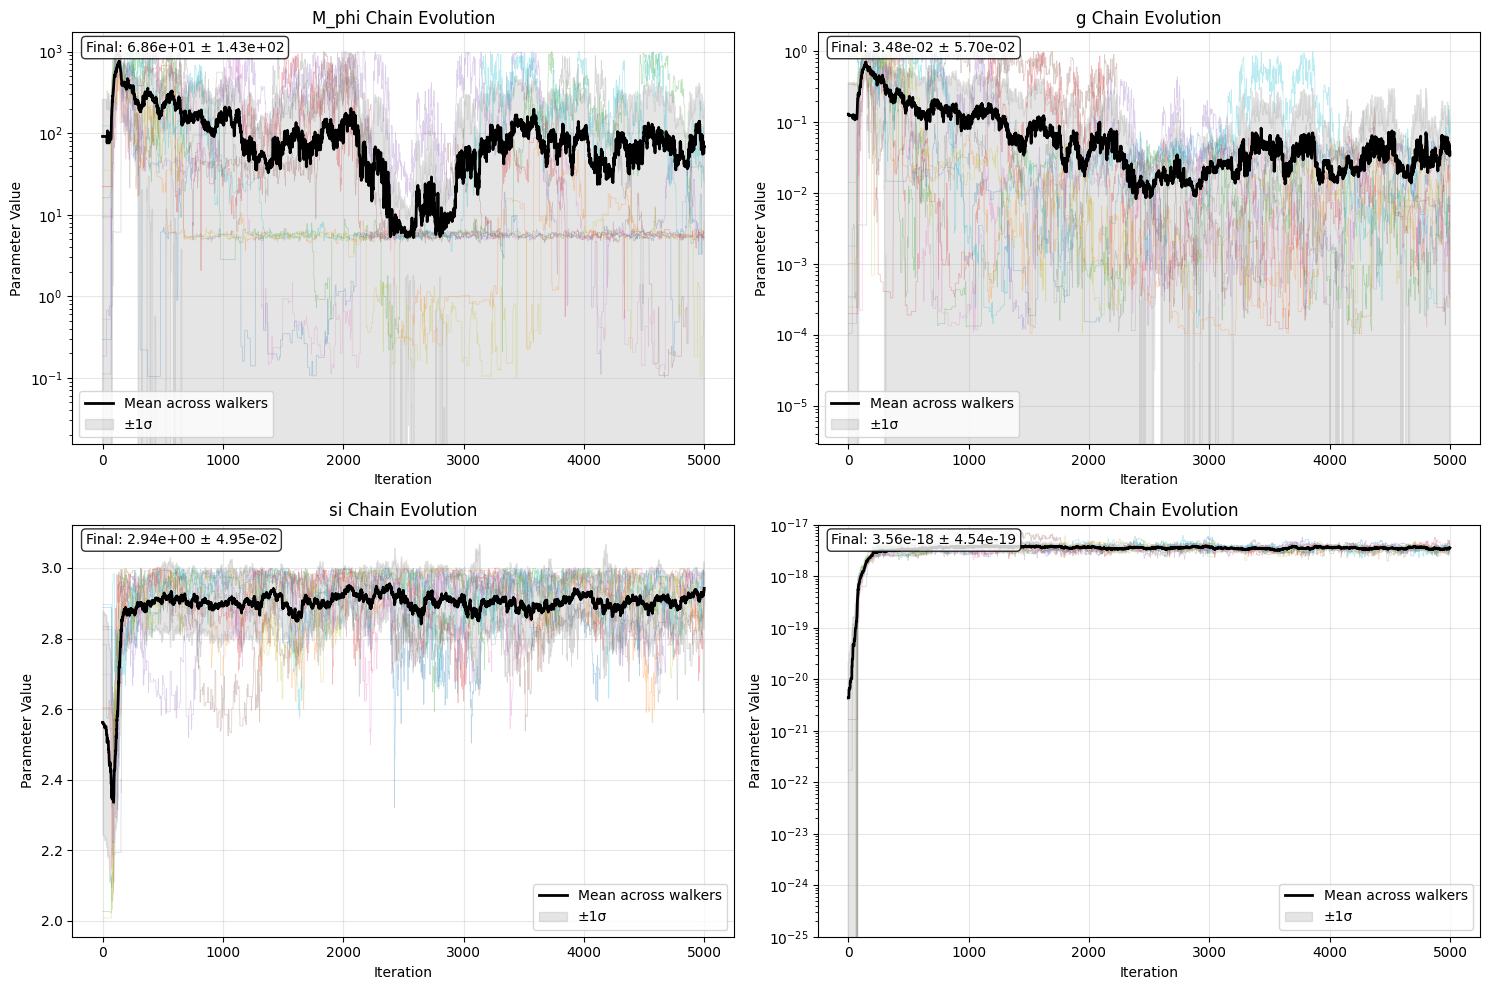

  Corner plot saved to 'mcmc_corner_plot.png'


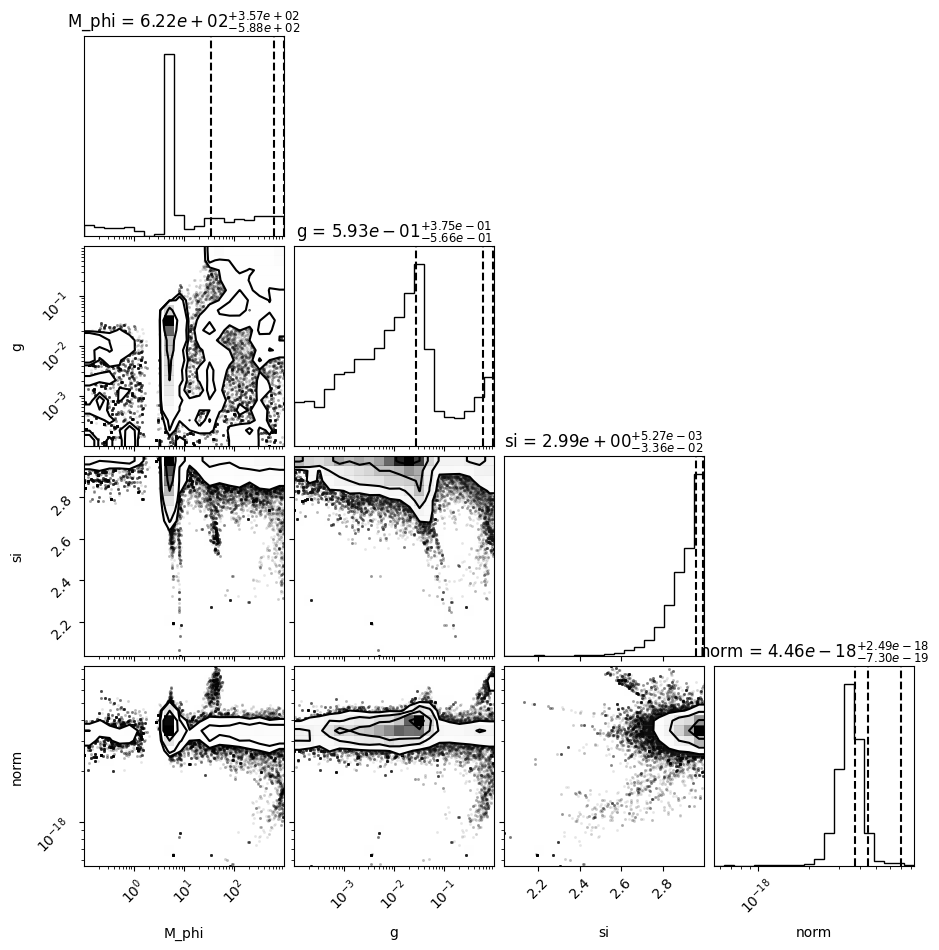

log prob shape (5000, 17)
Infinite log probabilities: 1067/85000 (1.3%)
Some walkers are exploring regions with zero likelihood
This is normal in MCMC - filtering out infinite values for mean calculation
mean log prob [-- -- -- ... 344.3779932370201 344.1712179650103 344.25084608413425]
  Likelihood evolution plot saved to 'mcmc_likelihood_evolution.png'


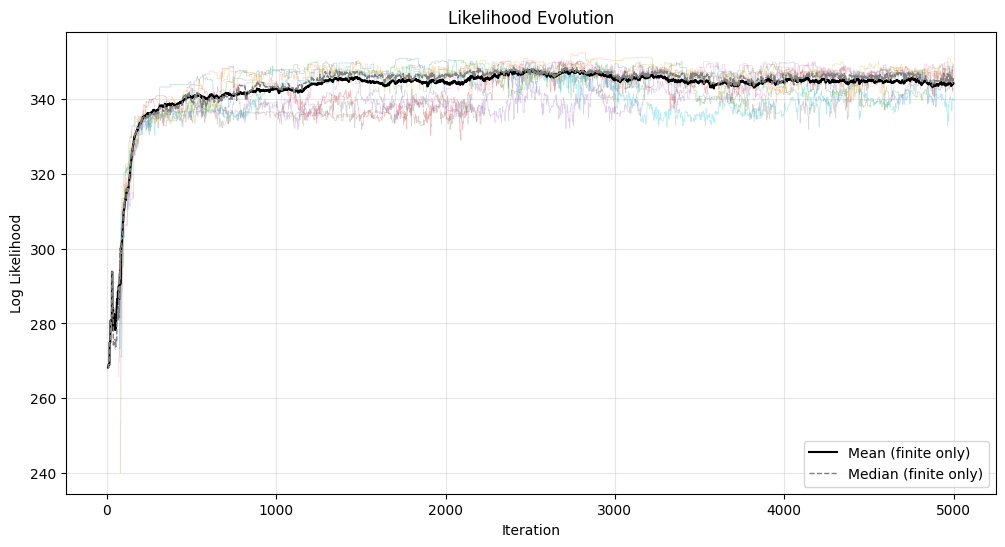

  Acceptance rate distribution saved to 'mcmc_acceptance_distribution.png'


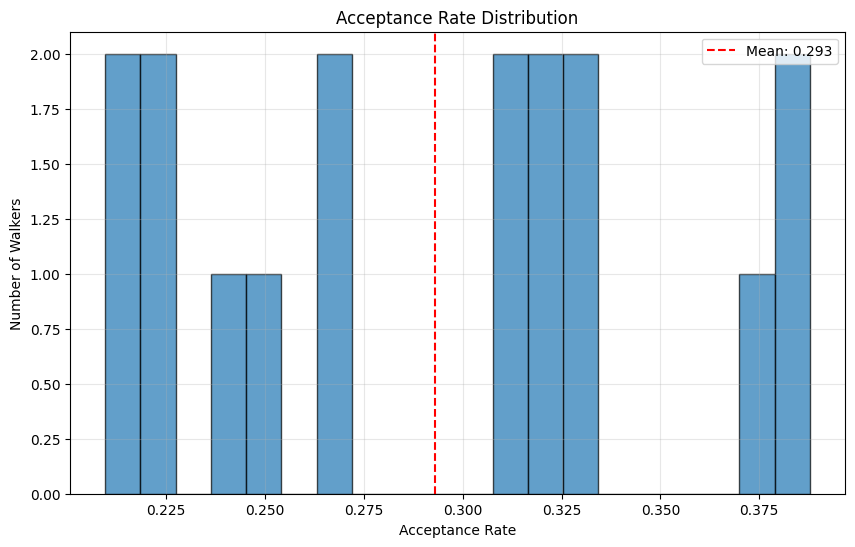

In [75]:
exec(open('analyze_completed_mcmc.py').read())

results = analyze_completed_mcmc(sampler)
plot_comprehensive_results(sampler)